# 01 — Exploratory Data Analysis

We profile the **customer risk** dataset before any modeling. This step validates data quality, class balance, and leakage risks.

## Objectives

- Confirm row counts, date coverage, and missing values
- Visualize the **binary target** (`high risk` = `global_risk_score >= 50`)
- Inspect distributions of tenure, balances, and compliance flags
- Check correlations that could leak the label into features

## Pipeline position

```mermaid
flowchart LR
    A[Raw / Warehouse] --> B[This notebook]
    B --> C[02 Feature Engineering]
    C --> D[03 Training]
```


In [1]:
from pathlib import Path
import sys

def find_ml_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / '4_ml' / 'src').exists():
            return candidate / '4_ml'
        if candidate.name == '4_ml' and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the 4_ml workspace.')

ML_ROOT = find_ml_root()
if str(ML_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ML_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from config import OUTPUT_DIR
from data_access import load_feature_frame
from features import build_targets, engineer_features, select_feature_columns

sns.set_theme(style='whitegrid', context='talk')
frame = load_feature_frame()
frame.head()

,fact_customer_risk_sk,customer_sk,customer_id,scoring_date,load_date,customer_tenure_days,account_count,total_working_balance,avg_working_balance,negative_balance_account_count,...,next_kyc_review_date,is_kyc_complete,is_pep,is_compliance_flagged,has_compliance_decision,posting_restriction_code,segment_code,client_nature_code,legal_capacity_flag,beneficial_owner_flag
0,1,1,113336184,2026-05-18,2026-05-18,3058,1.0,2.088,2.088,0.0,...,NaT,0,0,0,0,UNKNOWN,8.0,PPH,OUI,OUI
1,2,2,113199291,2026-05-18,2026-05-18,3058,1.0,-50.808,-50.808,1.0,...,NaT,1,0,0,0,UNKNOWN,8.0,PPH,OUI,OUI
2,3,3,113318555,2026-05-18,2026-05-18,3058,1.0,22900.274,22900.274,0.0,...,NaT,0,0,0,0,UNKNOWN,6.0,PPH,OUI,OUI
3,4,4,113160985,2026-05-18,2026-05-18,3058,NaN,NaN,NaN,NaN,...,NaT,0,0,0,0,UNKNOWN,NaN,PPH,OUI,OUI
4,5,5,113182752,2026-05-18,2026-05-18,3058,NaN,NaN,NaN,NaN,...,NaT,1,0,0,0,UNKNOWN,NaN,PPH,OUI,OUI


In [2]:
summary = {
    'rows': len(frame),
    'columns': frame.shape[1],
    'date_min': frame['scoring_date'].min(),
    'date_max': frame['scoring_date'].max(),
    'missing_pct': frame.isna().mean().sort_values(ascending=False).head(15),
}
summary['rows'], summary['columns'], summary['date_min'], summary['date_max']

(136676,
 44,
 Timestamp('2026-05-18 00:00:00'),
 Timestamp('2026-05-18 00:00:00'))

In [3]:
analysis_frame = engineer_features(build_targets(frame))
feature_columns, numeric_columns, categorical_columns = select_feature_columns(analysis_frame)
analysis_frame[['risk_target', 'global_risk_score', 'account_count', 'total_working_balance']].describe()

,risk_target,global_risk_score,account_count,total_working_balance
count,136676.000000,136676.000000,102059.000000,1.020590e+05
mean,0.013258,30.748774,1.090506,6.307134e+03
std,0.114376,9.516056,0.323051,1.273909e+05
min,0.000000,11.000000,1.000000,-1.613492e+07
25%,0.000000,22.250000,1.000000,1.496500e+00
50%,0.000000,29.500000,1.000000,4.853100e+01
75%,0.000000,39.750000,1.000000,1.745950e+03
max,1.000000,62.750000,20.000000,2.495270e+07


WindowsPath('C:/Users/Ahmed/Desktop/atb_bi_project/4_ml/outputs/eda_target_and_distribution.png')

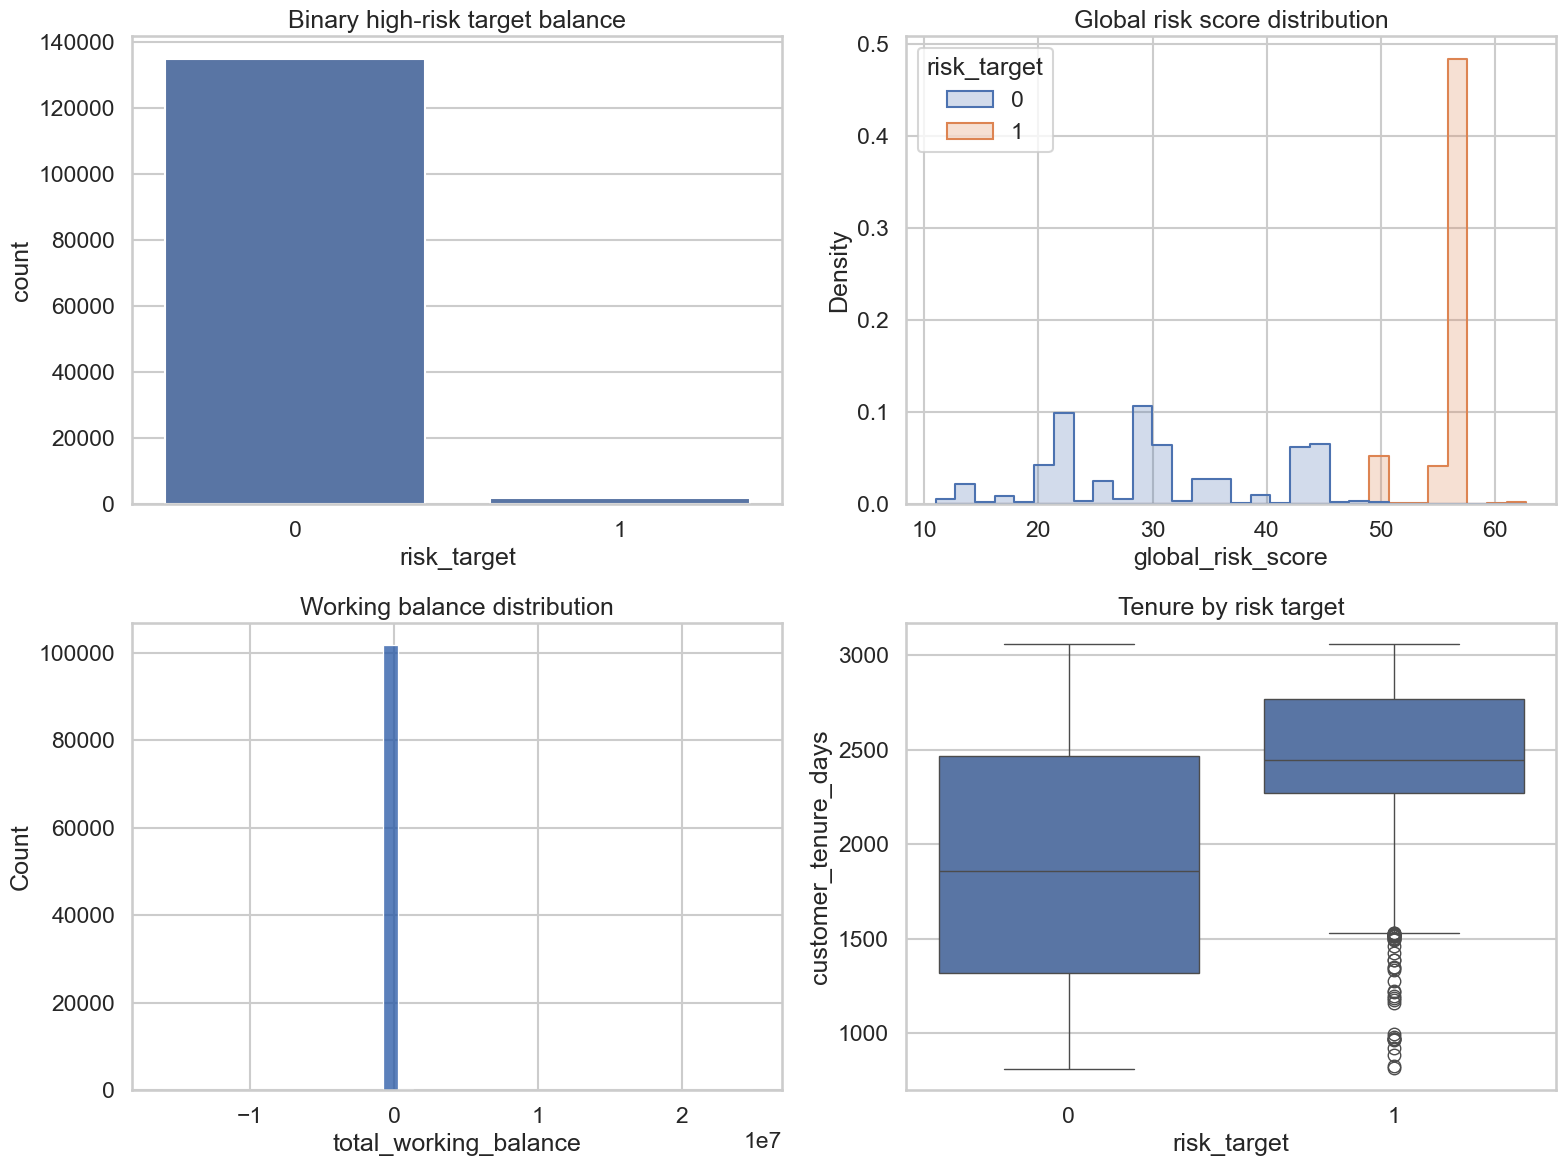

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=analysis_frame, x='risk_target', ax=axes[0, 0])
axes[0, 0].set_title('Binary high-risk target balance')

sns.histplot(data=analysis_frame, x='global_risk_score', hue='risk_target', bins=30, ax=axes[0, 1], element='step', stat='density', common_norm=False)
axes[0, 1].set_title('Global risk score distribution')

sns.histplot(data=analysis_frame, x='total_working_balance', bins=40, ax=axes[1, 0], color='#2455A4')
axes[1, 0].set_title('Working balance distribution')

sns.boxplot(data=analysis_frame, x='risk_target', y='customer_tenure_days', ax=axes[1, 1])
axes[1, 1].set_title('Tenure by risk target')

plt.tight_layout()
eda_plot_path = OUTPUT_DIR / 'eda_target_and_distribution.png'
fig.savefig(eda_plot_path, dpi=160, bbox_inches='tight')
eda_plot_path

WindowsPath('C:/Users/Ahmed/Desktop/atb_bi_project/4_ml/outputs/eda_correlation_heatmap.png')

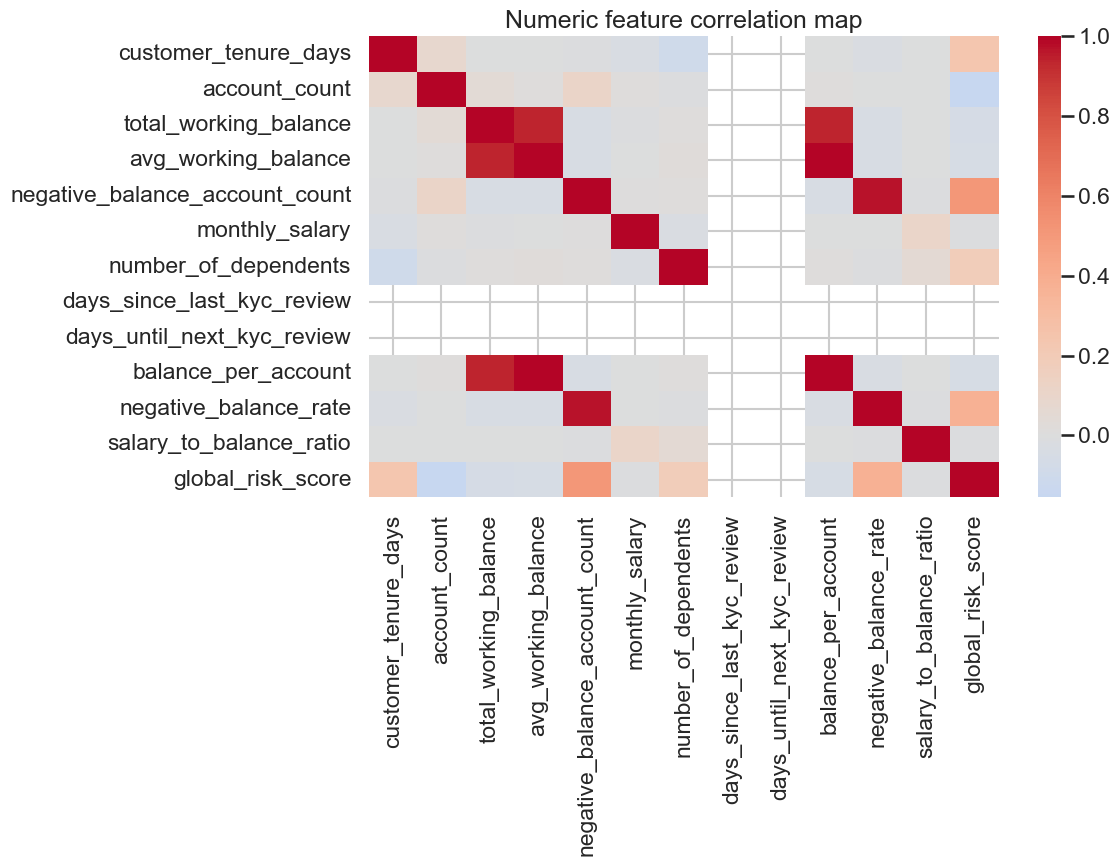

In [5]:
corr_cols = [
    column for column in [
        'customer_tenure_days', 'account_count', 'total_working_balance', 'avg_working_balance',
        'negative_balance_account_count', 'monthly_salary', 'number_of_dependents',
        'days_since_last_kyc_review', 'days_until_next_kyc_review', 'balance_per_account',
        'negative_balance_rate', 'salary_to_balance_ratio', 'global_risk_score'
    ] if column in analysis_frame.columns
]
corr = analysis_frame[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Numeric feature correlation map')
corr_plot_path = OUTPUT_DIR / 'eda_correlation_heatmap.png'
plt.tight_layout()
plt.savefig(corr_plot_path, dpi=160, bbox_inches='tight')
corr_plot_path

## What this EDA validates

- The binary target is derived from `global_risk_score >= 50` for the current supervised learning task.
- The modeling set is temporal, so the final split should be performed by `scoring_date` rather than randomly.
- The risk factors are rooted in customer profile, KYC, salary, balance, and account-activity signals described in the warehouse guide.

Optional churn modeling is intentionally left as a scaffold until a real churn label is available from closure or inactivity history.